In [3]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as mpl
import seaborn as sb
import missingno as msn
import warnings
warnings.filterwarnings('ignore')

print('OK')

OK


In [4]:
train = pd.read_parquet('C:/Users/Deepayan/Documents/MAVERICK/projects/churn-prediction/artifacts/kkbox_final.parquet')
print('OK')

OK


In [5]:
train.shape  #rows and coloumns in dataset 

(970960, 17)

In [6]:
train.head()

,msno,is_churn,city,bd,gender,registered_via,registration_init_time,transanction_count,last_plan_days,last_plan_price,avg_amount_paid,auto_renew_flag,cancel_count,total_secs,num_unq,num_100,days_active
0,ugx0CjOMzazClkFzU2xasmDZaoIqOUAZPsH1q0teWCg=,1,5.0,28.0,male,3.0,20131223.0,NaN,NaN,NaN,NaN,NaN,NaN,80598.557,348.0,318.0,11.0
1,f/NmvEzHfhINFEYZTR05prUdr+E+3+oewvweYz9cCQE=,1,13.0,20.0,male,3.0,20131223.0,1.0,30.0,180.0,180.0,0.0,0.0,6986.509,30.0,26.0,6.0
2,zLo9f73nGGT1p21ltZC3ChiRnAVvgibMyazbCxvWPcg=,1,13.0,18.0,male,3.0,20131227.0,2.0,90.0,300.0,150.0,0.0,0.0,67810.467,432.0,205.0,20.0
3,8iF/+8HY8lJKFrTc7iR9ZYGCG2Ecrogbc2Vy5YhsfhQ=,1,1.0,0.0,NaN,7.0,20140109.0,10.0,30.0,149.0,149.0,1.0,0.0,NaN,NaN,NaN,NaN
4,K6fja4+jmoZ5xG6BypqX80Uw/XKpMgrEMdG2edFOxnA=,1,13.0,35.0,female,7.0,20140125.0,8.0,30.0,99.0,99.0,1.0,1.0,239882.241,548.0,962.0,15.0


In [7]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 970960 entries, 0 to 970959
Data columns (total 17 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   msno                    970960 non-null  str    
 1   is_churn                970960 non-null  int64  
 2   city                    860967 non-null  float64
 3   bd                      860967 non-null  float64
 4   gender                  388905 non-null  str    
 5   registered_via          860967 non-null  float64
 6   registration_init_time  860967 non-null  float64
 7   transanction_count      933578 non-null  float64
 8   last_plan_days          933578 non-null  float64
 9   last_plan_price         933578 non-null  float64
 10  avg_amount_paid         933578 non-null  float64
 11  auto_renew_flag         933578 non-null  float64
 12  cancel_count            933578 non-null  float64
 13  total_secs              754551 non-null  float64
 14  num_unq                 754551 

In [8]:
train.select_dtypes(include = 'number').columns

Index(['is_churn', 'city', 'bd', 'registered_via', 'registration_init_time',
       'transanction_count', 'last_plan_days', 'last_plan_price',
       'avg_amount_paid', 'auto_renew_flag', 'cancel_count', 'total_secs',
       'num_unq', 'num_100', 'days_active'],
      dtype='str')

In [9]:
train.select_dtypes(include = 'object').columns

Index(['msno', 'gender'], dtype='str')

In [10]:
train['is_churn'].value_counts()

is_churn
0    883630
1     87330
Name: count, dtype: int64

In [ ]:
train.isna().sum()  #no. of missing values per column

msno                           0
is_churn                       0
city                      109993
bd                        109993
gender                    582055
registered_via            109993
registration_init_time    109993
transanction_count         37382
last_plan_days             37382
last_plan_price            37382
avg_amount_paid            37382
auto_renew_flag            37382
cancel_count               37382
total_secs                216409
num_unq                   216409
num_100                   216409
days_active               216409
dtype: int64

In [ ]:
train.duplicated().sum() #no. of duplicates

np.int64(0)

In [ ]:
train.nunique() #no. of unique elements per column

msno                      970960
is_churn                       2
city                          21
bd                           231
gender                         2
registered_via                 5
registration_init_time      4749
transanction_count            63
last_plan_days                29
last_plan_price               43
avg_amount_paid             1031
auto_renew_flag                2
cancel_count                   7
total_secs                752443
num_unq                     5122
num_100                     6782
days_active                   31
dtype: int64

In [17]:
train.head()

,msno,is_churn,city,bd,gender,registered_via,registration_init_time,transanction_count,last_plan_days,last_plan_price,avg_amount_paid,auto_renew_flag,cancel_count,total_secs,num_unq,num_100,days_active
0,ugx0CjOMzazClkFzU2xasmDZaoIqOUAZPsH1q0teWCg=,1,5.0,28.0,male,3.0,20131223.0,NaN,NaN,NaN,NaN,NaN,NaN,80598.557,348.0,318.0,11.0
1,f/NmvEzHfhINFEYZTR05prUdr+E+3+oewvweYz9cCQE=,1,13.0,20.0,male,3.0,20131223.0,1.0,30.0,180.0,180.0,0.0,0.0,6986.509,30.0,26.0,6.0
2,zLo9f73nGGT1p21ltZC3ChiRnAVvgibMyazbCxvWPcg=,1,13.0,18.0,male,3.0,20131227.0,2.0,90.0,300.0,150.0,0.0,0.0,67810.467,432.0,205.0,20.0
3,8iF/+8HY8lJKFrTc7iR9ZYGCG2Ecrogbc2Vy5YhsfhQ=,1,1.0,0.0,NaN,7.0,20140109.0,10.0,30.0,149.0,149.0,1.0,0.0,NaN,NaN,NaN,NaN
4,K6fja4+jmoZ5xG6BypqX80Uw/XKpMgrEMdG2edFOxnA=,1,13.0,35.0,female,7.0,20140125.0,8.0,30.0,99.0,99.0,1.0,1.0,239882.241,548.0,962.0,15.0


In [16]:
numeric_features = [feature for feature in train.columns if train[feature].dtype != 'O']
print('The dataset has {} numeric features: {}'.format(len(numeric_features), numeric_features))

The dataset has 17 numeric features: ['msno', 'is_churn', 'city', 'bd', 'gender', 'registered_via', 'registration_init_time', 'transanction_count', 'last_plan_days', 'last_plan_price', 'avg_amount_paid', 'auto_renew_flag', 'cancel_count', 'total_secs', 'num_unq', 'num_100', 'days_active']


In [18]:
categorical_features = [feature for feature in train.columns if train[feature].dtype == 'O']
print('The dataset has {} categorical features: {}'.format(len(categorical_features), categorical_features))

The dataset has 0 categorical features: []


In [19]:
train.describe()

,is_churn,city,bd,registered_via,registration_init_time,transanction_count,last_plan_days,last_plan_price,avg_amount_paid,auto_renew_flag,cancel_count,total_secs,num_unq,num_100,days_active
count,970960.000000,860967.000000,860967.000000,860967.000000,8.609670e+05,933578.000000,933578.000000,933578.000000,933578.000000,933578.000000,933578.000000,7.545510e+05,754551.000000,754551.000000,754551.000000
mean,0.089942,5.937295,13.583854,6.892744,2.013265e+07,1.212578,33.663370,144.050406,143.761684,0.913476,0.035223,1.397844e+05,511.878935,535.902252,17.935095
std,0.286099,6.441203,20.064040,1.937794,3.011174e+04,1.285981,32.088008,136.714883,133.723976,0.281137,0.187933,1.855241e+05,594.729644,763.731803,9.676949
min,0.000000,1.000000,-3152.000000,3.000000,2.004033e+07,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.500000e-02,1.000000,0.000000,1.000000
25%,0.000000,1.000000,0.000000,7.000000,2.012021e+07,1.000000,30.000000,99.000000,99.000000,1.000000,0.000000,3.020290e+04,124.000000,108.000000,9.000000
50%,0.000000,1.000000,0.000000,7.000000,2.014060e+07,1.000000,30.000000,149.000000,149.000000,1.000000,0.000000,8.264024e+04,330.000000,305.000000,19.000000
75%,0.000000,13.000000,27.000000,9.000000,2.016012e+07,1.000000,30.000000,149.000000,149.000000,1.000000,0.000000,1.757171e+05,680.000000,660.000000,27.000000
max,1.000000,22.000000,2016.000000,13.000000,2.017042e+07,208.000000,450.000000,2000.000000,2000.000000,1.000000,8.000000,1.433739e+07,23403.000000,57675.000000,31.000000


AttributeError: Rectangle.set() got an unexpected keyword argument 'colour'

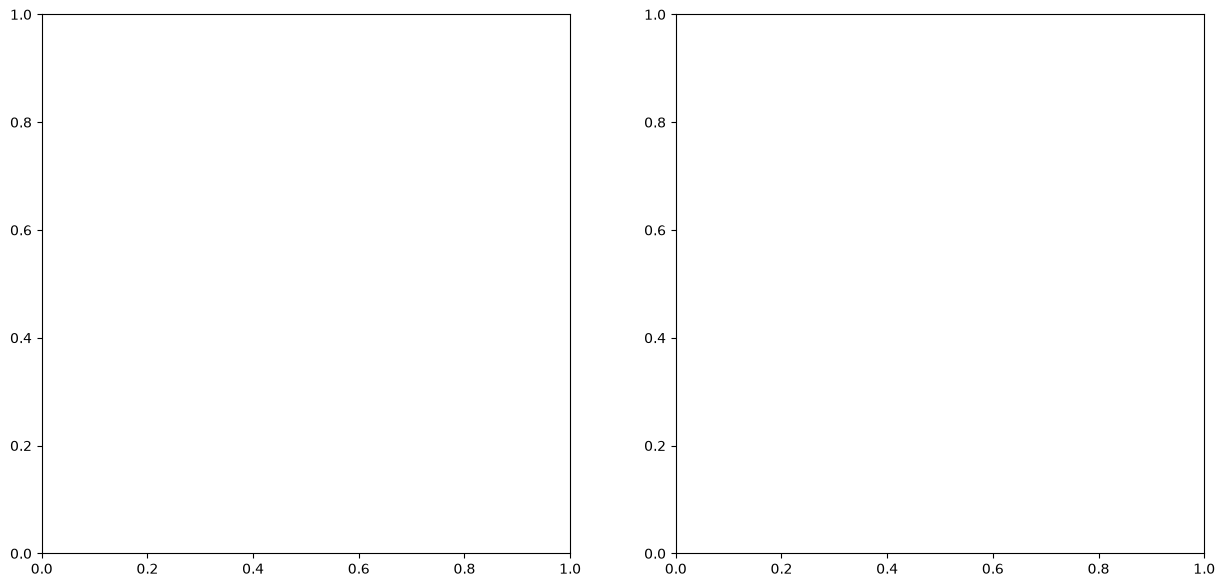

In [20]:
fig, axis = mpl.subplots(1, 2, figsize = (15, 7))
mpl.subplot(121)
sb.histplot(data = train, x = 'avg_amount_paid', kde = True, colour = 'g')
mpl.subplot(122)
sb.histplot(data = train, x = 'avg_amount_paid', kde = True, hue = 'gender')
mpl.show()